In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [6]:
df = pd.read_csv('Algerian_forest_fires_dataset_cleaned.csv')
df.head(5)

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [7]:
### drop day, month year

df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='str')

In [8]:
df.drop(['day', 'month', 'year'], axis=1, inplace=True)

In [9]:
df['Classes'].value_counts()

Classes
fire             129
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [10]:
### Encoding of classes

df['Classes'] = np.where(df['Classes'].str.contains('not fire'), 0, 1)

In [11]:
df['Classes'].value_counts()

Classes
1    135
0    106
Name: count, dtype: int64

In [12]:
df.columns

Index(['Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI',
       'FWI', 'Classes', 'Region'],
      dtype='str')

In [13]:
### Independent and dependent feaatures

x = df.drop('FWI', axis = 1)
y = df['FWI']

In [14]:
### Train test split
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

In [15]:
### Feature selection based on correlation matrix

df.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
Temperature,1.000000,-0.652097,-0.285492,-0.326628,0.677222,0.486202,0.377551,0.603940,0.460248,0.566198,0.517362,0.270088
RH,-0.652097,1.000000,0.245439,0.224455,-0.649202,-0.412498,-0.229227,-0.687424,-0.357018,-0.581746,-0.437535,-0.408294
Ws,-0.285492,0.245439,1.000000,0.173519,-0.170108,-0.002172,0.081250,0.005276,0.030926,0.030262,-0.074210,-0.186638
Rain,-0.326628,0.224455,0.173519,1.000000,-0.543222,-0.288048,-0.299841,-0.346942,-0.299663,-0.323661,-0.377754,-0.037010
FFMC,0.677222,-0.649202,-0.170108,-0.543222,1.000000,0.603407,0.511495,0.739492,0.592680,0.690301,0.768627,0.217984
DMC,0.486202,-0.412498,-0.002172,-0.288048,0.603407,1.000000,0.878189,0.682237,0.982407,0.876786,0.585431,0.190264
DC,0.377551,-0.229227,0.081250,-0.299841,0.511495,0.878189,1.000000,0.514684,0.943254,0.743684,0.516409,-0.075464
ISI,0.603940,-0.687424,0.005276,-0.346942,0.739492,0.682237,0.514684,1.000000,0.646662,0.922996,0.735528,0.259318
BUI,0.460248,-0.357018,0.030926,-0.299663,0.592680,0.982407,0.943254,0.646662,1.000000,0.859341,0.587669,0.088755
FWI,0.566198,-0.581746,0.030262,-0.323661,0.690301,0.876786,0.743684,0.922996,0.859341,1.000000,0.719271,0.194166


<Axes: >

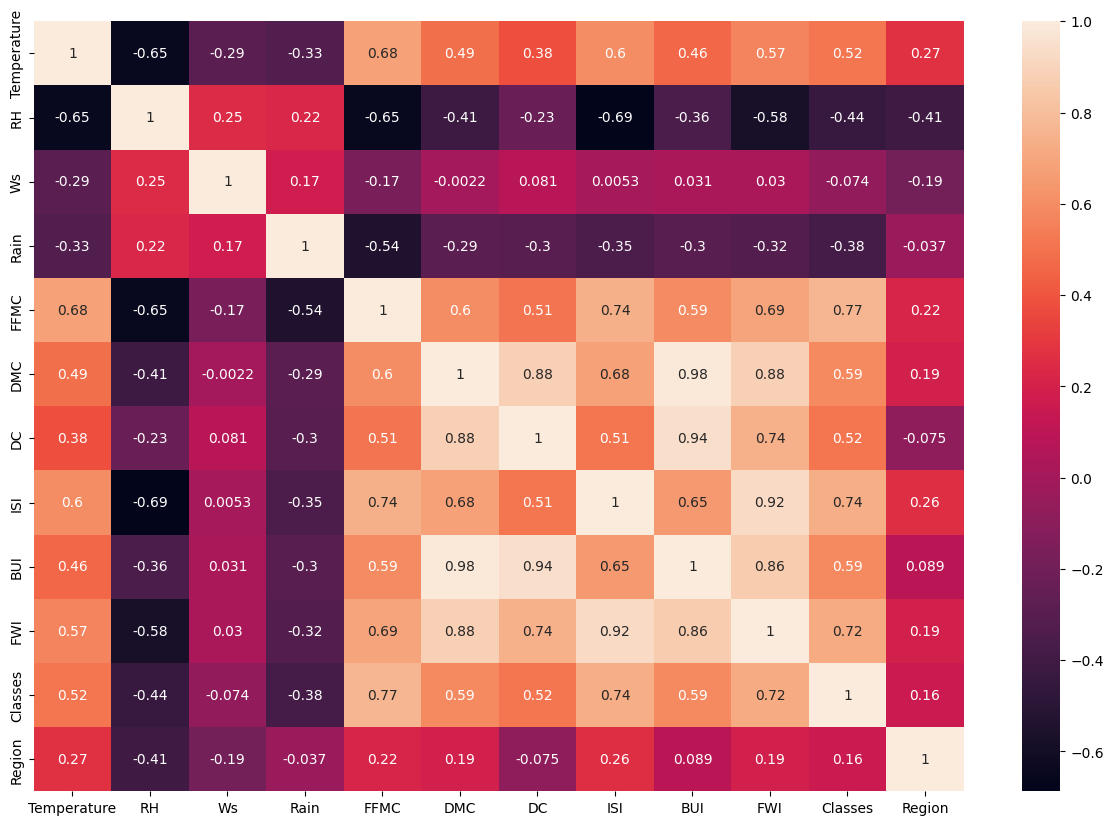

In [17]:
plt.figure(figsize=(15, 10))
sns.heatmap(df.corr(), annot = True)

In [18]:
### Check for multicollinearity

def correlation(dataset, threshold):
    col_corr = set()  # Set of all the names of deleted columns
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:  # we are interested in absolute coeff value
                colname = corr_matrix.columns[i]  # getting the name of column
                col_corr.add(colname)

    return col_corr



In [ ]:
corr_features = correlation(x_train, 0.85)

In [20]:
### drop features with high correlation 0.85

x_train.drop(corr_features, axis=1, inplace=True)
x_test.drop(corr_features, axis=1, inplace=True)

x_train.shape, x_test.shape

((180, 9), (61, 9))

In [21]:
### Feature Scaling and standardization

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [22]:
x_train_scaled

array([[-0.80936393,  0.77963874,  1.26547279, ..., -0.6133585 ,
        -1.09321633, -0.97801929],
       [-0.02045324,  0.30894166, -0.55972835, ..., -0.87719727,
        -1.09321633,  1.02247472],
       [ 2.08330859, -2.1117862 , -0.19468812, ...,  2.86451613,
         0.91473203,  1.02247472],
       ...,
       [-1.86124484,  0.91412362,  0.53539233, ..., -1.06908001,
        -1.09321633, -0.97801929],
       [ 1.2943979 , -0.49796763, -0.19468812, ...,  0.87373272,
         0.91473203,  1.02247472],
       [-0.5463937 ,  0.98136606,  1.99555324, ..., -0.85321193,
        -1.09321633, -0.97801929]], shape=(180, 9))

Text(0.5, 1.0, 'Data after Standard Scaling')

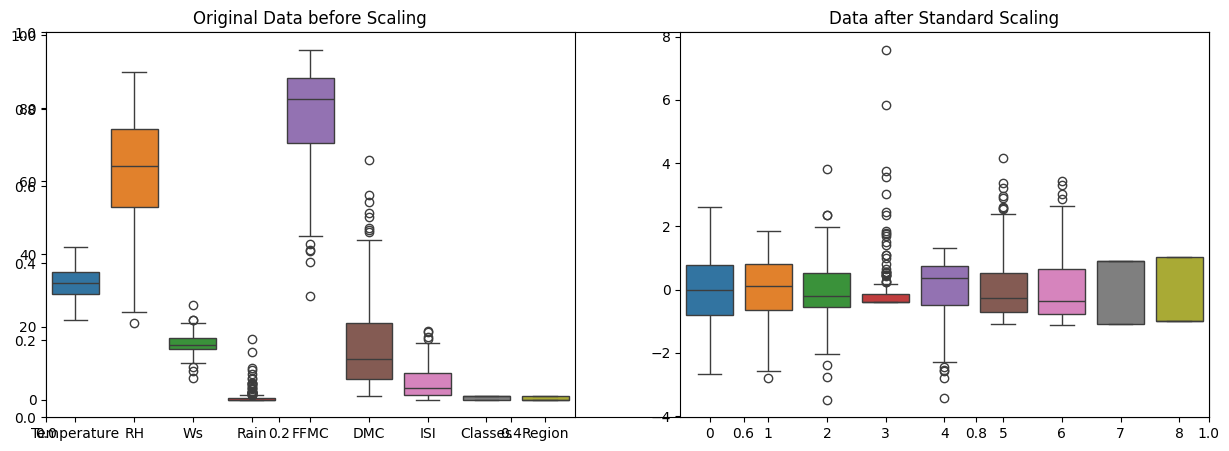

In [23]:
#### Boxplot to understand effect of standard scaler on features

plt.subplots(figsize=(15, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=x_train)
plt.title('Original Data before Scaling')

plt.subplot(1, 2, 2)
sns.boxplot(data=x_train_scaled)
plt.title('Data after Standard Scaling')

Mean Squared Error: 0.8537564271317223
R-squared: 0.9850683220529339


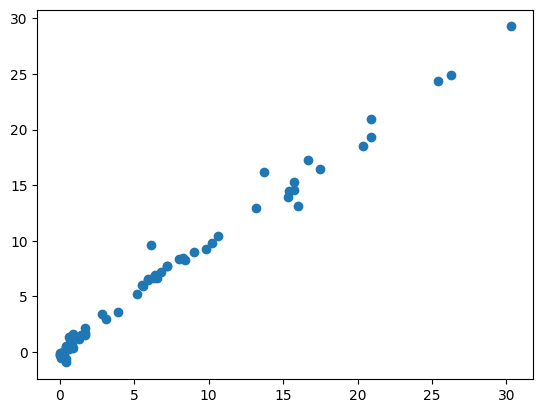

In [24]:
#### model Training

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

model = LinearRegression()
model.fit(x_train_scaled, y_train)

y_pred = model.predict(x_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

plt.scatter(y_test, y_pred)

Mean Squared Error: 2.983682149933977
R-squared: 0.9478172233398015


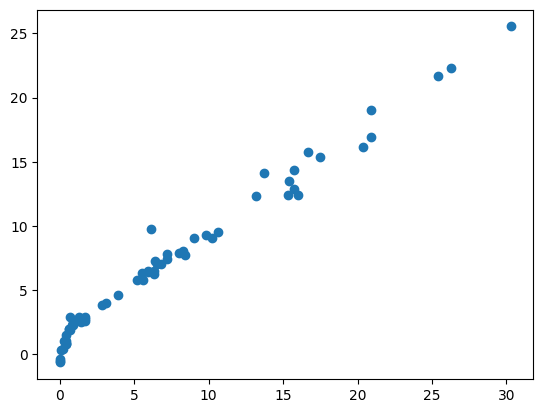

In [25]:
#### model Training for Lasso

from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score

model1 = Lasso()
model1.fit(x_train_scaled, y_train)

y_pred = model1.predict(x_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

plt.scatter(y_test, y_pred)

Mean Squared Error: 0.8909231592195211
R-squared: 0.9844182986314479


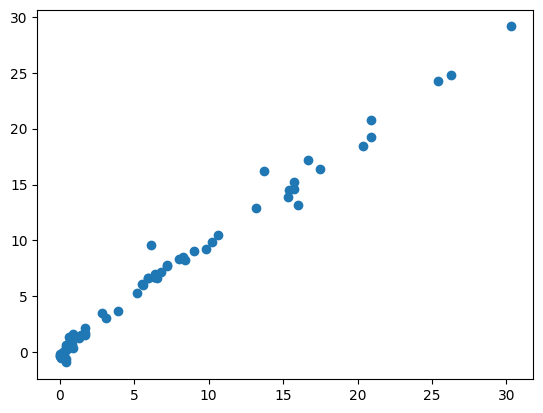

In [26]:
#### model Training ridge

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

model2 = Ridge()
model2.fit(x_train_scaled, y_train)

y_pred = model2.predict(x_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

plt.scatter(y_test, y_pred)

Mean Squared Error: 7.078634266799199
R-squared: 0.8761990143582201


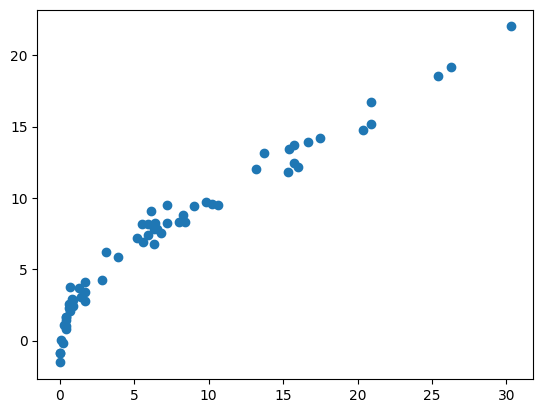

In [27]:
#### model Training with elasticnet

from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error, r2_score

model3 = ElasticNet()
model3.fit(x_train_scaled, y_train)

y_pred = model3.predict(x_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

plt.scatter(y_test, y_pred)

In [ ]:
### Cross Validation Lasso

from sklearn.linear_model import LassoCV

lassocv = LassoCV()